In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [2]:
a = 0.1
b = 0.9
u_star = a + b
v_star = b / ((a+b)**2)
L, N, D = 1, 200, 10
gamma = 1000

In [3]:
def M_matrix(k, gamma, u, v, D):
    j11 = (2* gamma * u * v) - (k**2) - gamma
    j12 = gamma * u**2
    j21 = -(2*gamma*u*v)
    j22 = -(gamma * u**2) - (k**2 * D)
    return np.array([[j11, j12],
                     [j21, j22]])

In [4]:
J = M_matrix(0, gamma= gamma, u=u_star, v=v_star, D=D)

In [35]:
tr_M = np.trace(J)
det_M = np.linalg.det(J)

print(f"turing conditions for reaction-diffusion")
print(f"trace(M) is negative:  {tr_M:.4f} < 0")
print(f"det(M) is positive: {det_M:.4f} > 0")


turing conditions for reaction-diffusion
trace(M) is negative:  -200.0000 < 0
det(M) is positive: 1000000.0000 > 0


In [6]:
def growth_numerical(k, gamma, u, v, D):
    M = M_matrix(k=k, gamma=gamma, u=u, v=v, D=D)
    eigs = np.linalg.eigvals(M)
    return np.max(eigs.real)

In [7]:
def growth_analytical(k, gamma, u, v, D):
    M = M_matrix(k=k, gamma=gamma, u=u, v=v, D=D)
    tr_M = np.trace(M)
    det_M = np.linalg.det(M)
    disc =  (tr_M**2) - (4 * det_M)
    return np.real((tr_M + np.emath.sqrt(disc))/2)

In [8]:
counter = []

for k in np.linspace(0, 30, 100):
    num = growth_numerical(k, gamma=gamma, u=u_star, v=v_star, D=D)
    ana = growth_analytical(k, gamma=gamma, u=u_star, v=v_star, D=D)

    counter.append(np.isclose(ana, num, rtol=1e-5))

print(rf"Matching points: {sum(counter)} / 100")

Matching points: 100 / 100


In [9]:
def det_coeff(gamma, u, v, D):
    A = D
    B = gamma*((u**2) + D - (2*D*u*v))
    C = (gamma**2) * (u**2)
    return A, B, C

In [10]:
def determinant(D, gamma, u, v, ):
    A, B, C = det_coeff(gamma, u, v, D)
    return ((B**2) - (4*A*C))

In [11]:
D_c = brentq(determinant, 5, 10, args=(gamma, u_star,v_star))
print(f"Critical D_c: {D_c:.4f}")


A_c, B_c, C_c = det_coeff(gamma, u_star, v_star, D_c)

assert (
    B_c < 0
), f"Spurious root detected! B = {B_c:.4f} must be negative for valid Turing modes."

print(f"Verified Critical D_c: {D_c:.4f} (B_c = {B_c:.2f} < 0)")

Critical D_c: 8.5676
Verified Critical D_c: 8.5676 (B_c = -5854.10 < 0)


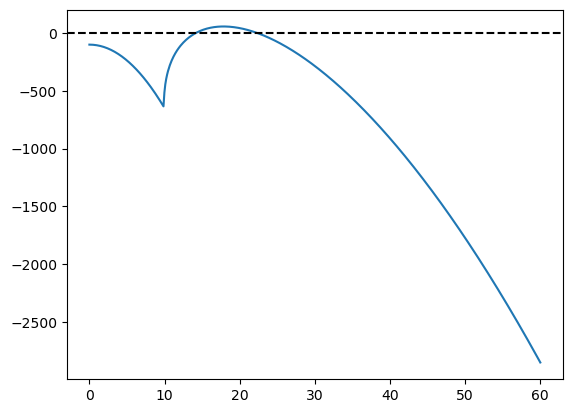

In [12]:
k = np.linspace(0, 60, 500)
lam = np.array([growth_numerical(ki, gamma= gamma, u=u_star, v=v_star, D=D) for ki in k])
plt.plot(k,lam)
plt.axhline(0, c='black', ls= '--')

In [13]:
peak = k[np.argmax(lam)] # k_critical

In [14]:
z = gamma*(((2*D*v_star*u_star) - (u_star**2) - D) / (2*D)) # k^2_critical

In [15]:
print(f"Numerical k peak:   {peak:.4f}")
print(f"Analytical k peak:  {np.sqrt(z):.4f}")
print(f"Absolute Difference: {abs(peak - np.sqrt(z)):.4f}")

Numerical k peak:   17.7956
Analytical k peak:  18.7083
Absolute Difference: 0.9127


In [25]:
n = np.arange(1,20)
k_n = (n * np.pi) / L

In [31]:
lam_n = np.array([
    growth_numerical(k, gamma= gamma, u=u_star, v=v_star, D=20) for k in k_n
    ])

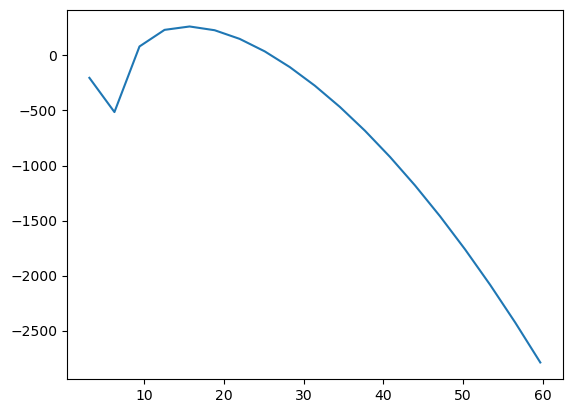

In [32]:
plt.plot(k_n, lam_n)

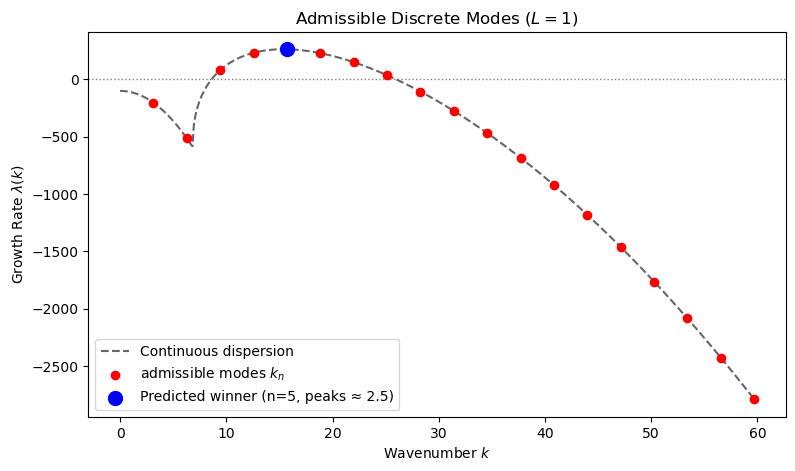

In [33]:
winning_idx = np.argmax(lam_n)
winning_n = n[winning_idx]
winning_k = k_n[winning_idx]
winning_lam = lam_n[winning_idx]

k_dense = np.linspace(0, max(k_n), 500)
lam_dense = np.array(
    [
        growth_numerical(k_val, gamma=1000, u=u_star, v=v_star, D=20)
        for k_val in k_dense
    ]
)

plt.figure(figsize=(9, 5))
plt.plot(k_dense, lam_dense, "k--", alpha=0.6, label="Continuous dispersion")
plt.scatter(k_n, lam_n, zorder = 3, c='red', label=rf'admissible modes $k_n$')
plt.scatter(
    [winning_k],
    [winning_lam],
    color="blue",
    s=100,
    zorder=3,
    label=f"Predicted winner (n={winning_n}, peaks ≈ {winning_n/2:.1f})",
)

plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Wavenumber $k$")
plt.ylabel("Growth Rate $\\lambda(k)$")
plt.title(
    f"Admissible Discrete Modes ($L={L}$)"
)
plt.legend()

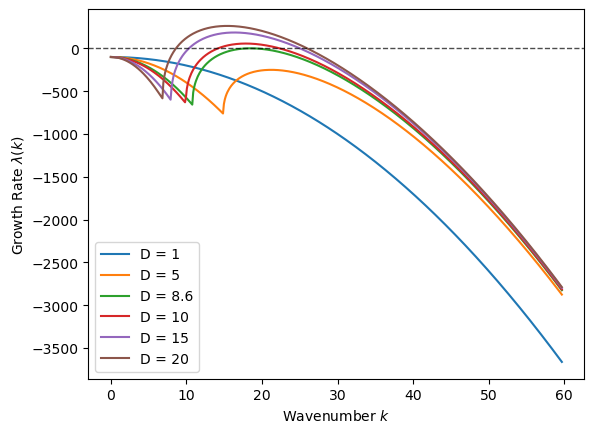

In [34]:
for d in [1,5, 8.6, 10,15,20]:
    k_dense_ds = np.linspace(0, max(k_n), 500)
    lam_dense_ds = np.array(
        [
            growth_numerical(k_val, gamma=gamma, u=u_star, v=v_star, D=d) for k_val in k_dense_ds
        ]
    )
    plt.plot(k_dense_ds, lam_dense_ds, label= rf'D = {d}')
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.xlabel("Wavenumber $k$")
plt.ylabel("Growth Rate $\\lambda(k)$")
plt.legend()